# The three-qubit bit-flip code

Encode one qubit into three, flip one of them, find the flip from two parity checks, fix it. The code lives in `src/bit_flip_code.py`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
import matplotlib.pyplot as plt
import numpy as np
from qiskit.quantum_info import Statevector

from src.bit_flip_code import bit_flip_circuit, logical_error_rate, run

An X error on q1 sits between the two barriers. The ancillas q3 and q4 read out the parities q0 xor q1 and q1 xor q2, and the `if_test` blocks apply the fix.

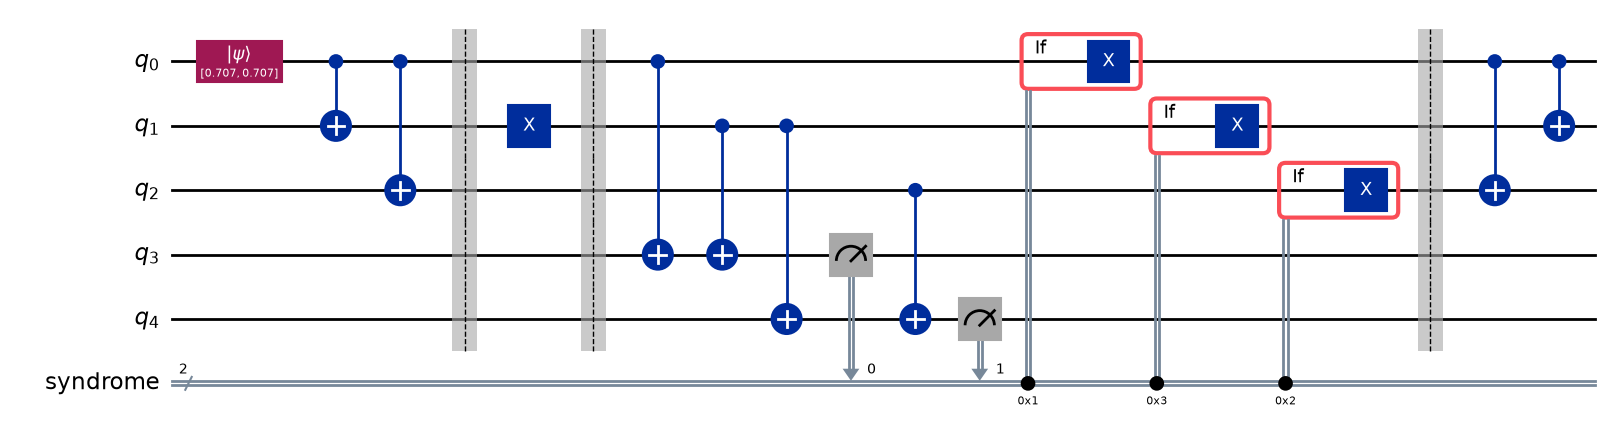

In [2]:
bit_flip_circuit(Statevector.from_label("+"), errors=[1]).draw("mpl", fold=-1)

In [3]:
state = Statevector.from_label("r")
print("errors   syndrome  fixed  fidelity")
for errors in [(), (0,), (1,), (2,), (0, 2)]:
    r = run(state, errors, seed=0)
    print(f"{str(errors):<8} {r.syndrome:02b}        {r.corrected_qubit!s:<6} {r.fidelity:.3f}")

errors   syndrome  fixed  fidelity
()       00        None   1.000
(0,)     01        0      1.000


(1,)     11        1      1.000
(2,)     10        2      1.000
(0, 2)   11        1      0.000


Two flips fool the decoder: it "fixes" the third qubit and the logical qubit ends up flipped.

## When does encoding pay off?

If each qubit flips with probability p, the code fails when two or three flip: 3p² − 2p³. That beats a bare qubit for p < 1/2.

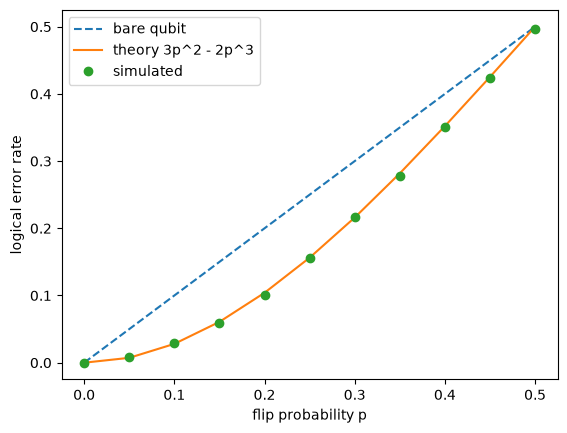

In [4]:
ps = np.linspace(0, 0.5, 11)
simulated = [logical_error_rate(p, shots=4000, seed=1) for p in ps]

plt.plot(ps, ps, "--", label="bare qubit")
plt.plot(ps, 3 * ps**2 - 2 * ps**3, label="theory 3p^2 - 2p^3")
plt.plot(ps, simulated, "o", label="simulated")
plt.xlabel("flip probability p")
plt.ylabel("logical error rate")
plt.legend();